### Test 200

Synchrony and directionality exhibit other transitions that aren't dependent on the 'bursting' transition.

What could these transitions be associated with? 

We might be able to identify these by changing the waveform of the autapse...

#### 1. Peak in directionality at f ~ 40 pA
    This is due to E1 spiking right before E2 for some spikes - is probably just conicdental but skews the SPIKE directionality
    This could be facilitated by the increased excitability of E1, but not consistent across all f.

#### 2. Peak in directionality and drop in CV_ISI at f ~ 150 pA
    Same as above coincidental spike timing.
    
    Drop in CV ISI is because the peak finding function is weak. Should be identifying 2 narrow peaks instead of 1.

#### 3. 


In [1]:
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 
from aqua.plotting_functions import *
from aqua.stimulus import OU_current

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns
import pyspike as spk
import pickle
import gc
import tracemalloc
from scipy.signal import convolve, windows
from scipy.stats import wasserstein_distance
from scipy.ndimage import gaussian_filter

from FT_metrics import *
from functions import *

WARNING    /home/liam/anaconda3/envs/aqua/lib/python3.14/site-packages/pyspike/__init__.py:40: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
 [py.warnings]


In [2]:
tag = 'test200'
filename = f"burst_analysis_{tag}TRACES.pickle"
with open(filename, 'rb') as file:
    data = pickle.load(file)

print(data.keys())

filename = f"burst_analysis_{tag}.pickle"
with open(filename, 'rb') as file:
    test200 = pickle.load(file)

print(test200.head())


time = data['time']
N_iter = len(time)
dt = time[1] - time[0]
T = N_iter * dt

f_vals = data['f']

spikes_E1 = data['spikes_E1']
spikes_E2 = data['spikes_E2']

bin1 = binarise_spikes(spikes_E1, dt, N_iter)
bin2 = binarise_spikes(spikes_E2, dt, N_iter)

X_E1 = data['X_E1']
X_E2 = data['X_E2']

# Autapse values to inspect
f1 = np.array([0, 20, 30, 35, 40, 45, 60])                              # represents the bump at the start
idx1_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f1])

f2 = np.array([145, 150, 155, 165])                                      # represents the tiny bump in the middle
idx2_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f2])

f3 = np.array([200, 220, 240, 258, 263, 300, 320, 330, 350])                            # right after the transition
idx3_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f3])

f4 = np.array([400, 420, 430, 445])
idx4_arr = np.array([np.argmin(np.abs(f_vals - f)) for f in f4])


dict_keys(['e', 'f', 'tau', 'time', 'X_E1', 'X_E2', 'I_E1', 'I_E2', 'spikes_E1', 'spikes_E2'])
   sim_number neuron_label    e    f  tau  I_inj   W  FT_distance     FT_EMD  \
0           0           E1  0.2  0.0  2.0    200  56     13.92583  41.839634   
1           0           E1  0.2  0.0  2.0    200  56     13.92583  41.839634   
2           0           E2  0.2  0.0  2.0    200  56     13.92583  41.839634   
3           0           E2  0.2  0.0  2.0    200  56     13.92583  41.839634   
4           0           E2  0.2  0.0  2.0    200  56     13.92583  41.839634   

   SPIKE_distance  ...  peak_isi  peak_number       mean       std  count_sum  \
0        0.240449  ...     59.75            1  59.984177  0.502119         79   
1        0.240449  ...     64.75            2  62.922996  2.138069        237   
2        0.240449  ...     87.75            1  87.950000  0.244949         20   
3        0.240449  ...     91.25            2  92.956667  1.988456         75   
4        0.240449  

In [3]:
## Initial plots for the directionality transition at f = 90

split = np.arange(0, 20000, 1)

def plot_leader(idx_arr, bin1, bin2, f_vals, split):
    fig, ax = plt.subplots(1, 1, figsize = (10, 5))


    for n, idx in enumerate(idx_arr):
        ax.plot(time[split], 2.*n + np.cumsum(bin1[idx, split] - bin2[idx, split]), label = f'f = {f_vals[idx]}')
        ax.text(x = -600, y = 2.*n, s = f'f = {np.round(f_vals[idx], 1)}')

    #ax.legend(loc = (1.01, .43))
    ax.set_xlim(-700, 1.1*time[split][-1])

    return fig, ax



(<Figure size 1000x500 with 1 Axes>, <Axes: >)

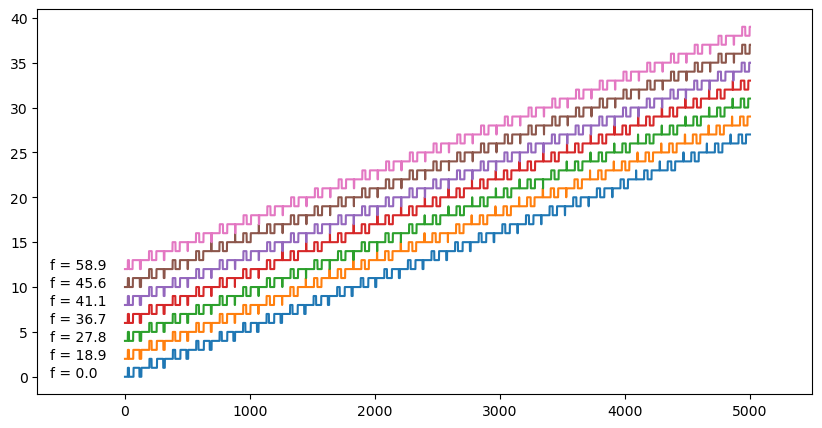

In [4]:
split = np.arange(0, 50000, 1)
plot_leader(idx1_arr, bin1, bin2, f_vals, split)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

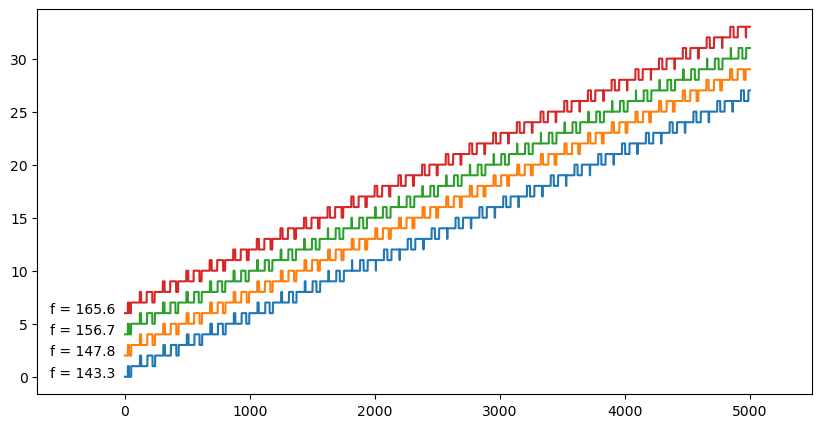

In [5]:
plot_leader(idx2_arr, bin1, bin2, f_vals, split)

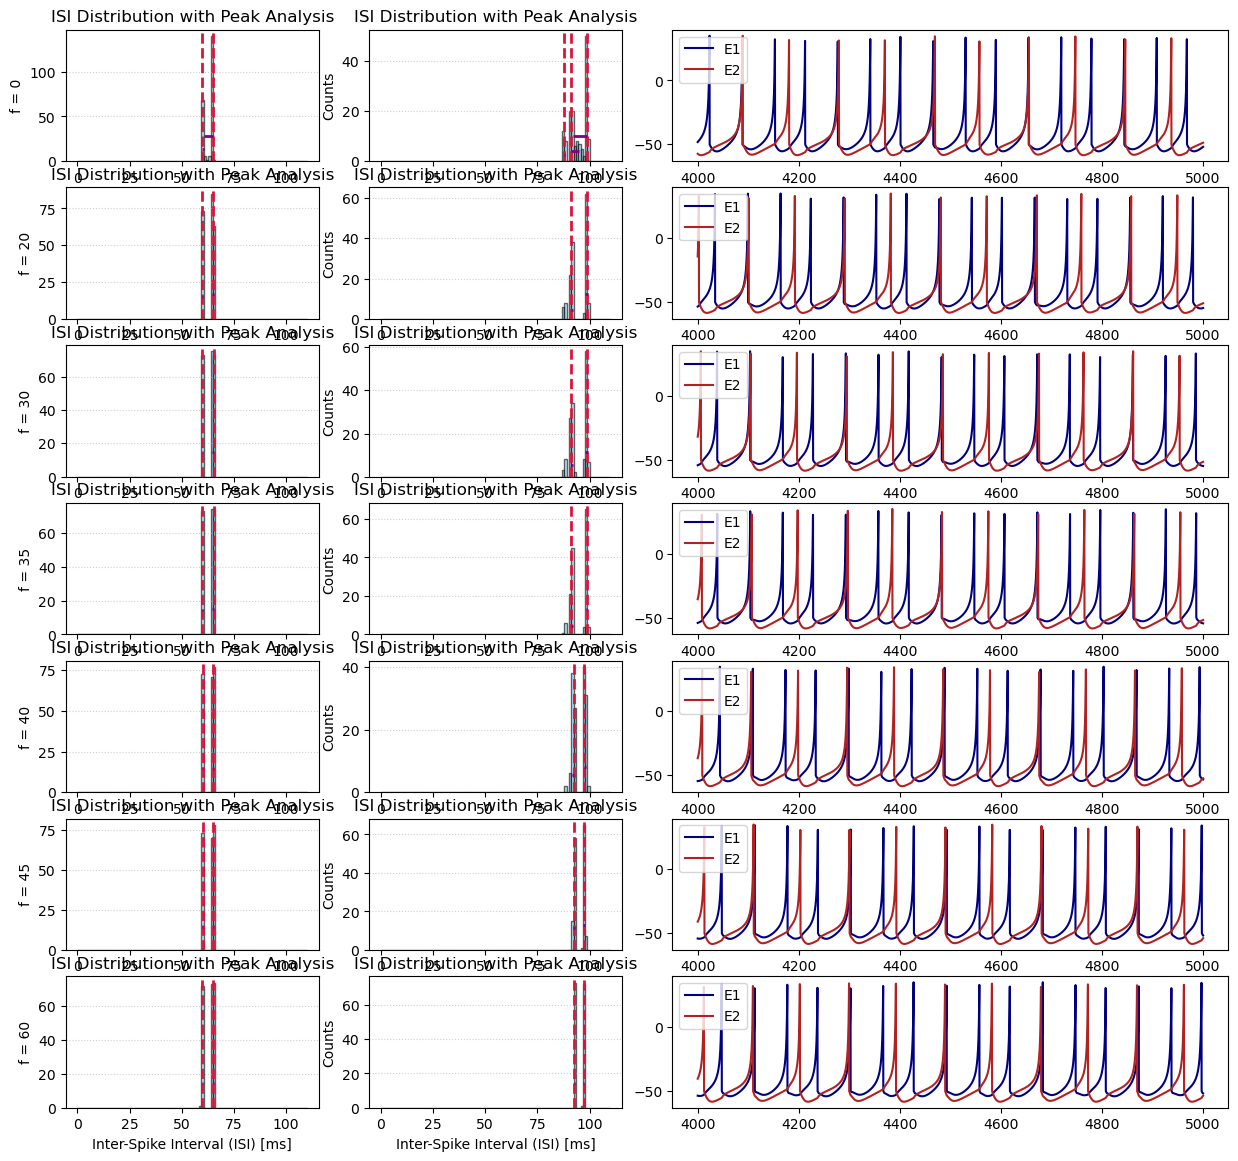

In [ ]:
# plot ISI distributions for f1

fig1, ax1 = plot_peak_and_series(f1, idx1_arr, spikes_E1, spikes_E2, X_E1, X_E2, test200, f_vals, time

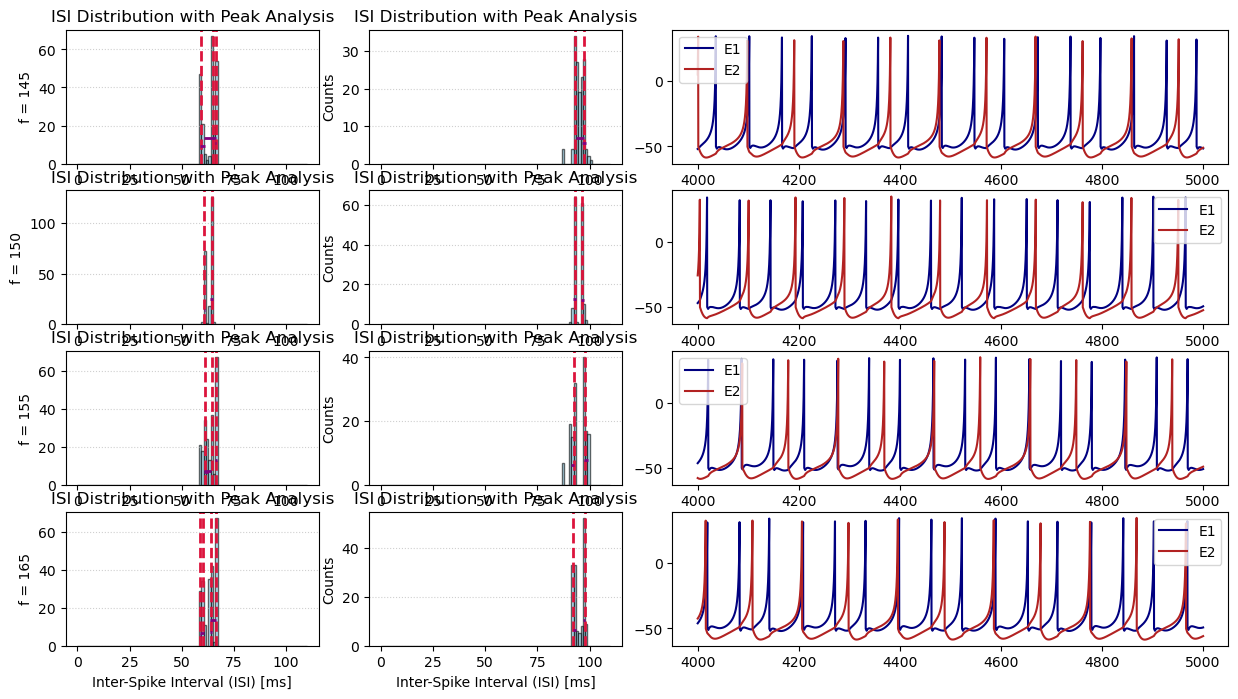

In [7]:
# plot ISI distributions for f1

fig2, ax2 = plot_peak_and_series(f2, idx2_arr, spikes_E1, spikes_E2, X_E1, X_E2, test200, f_vals, time)

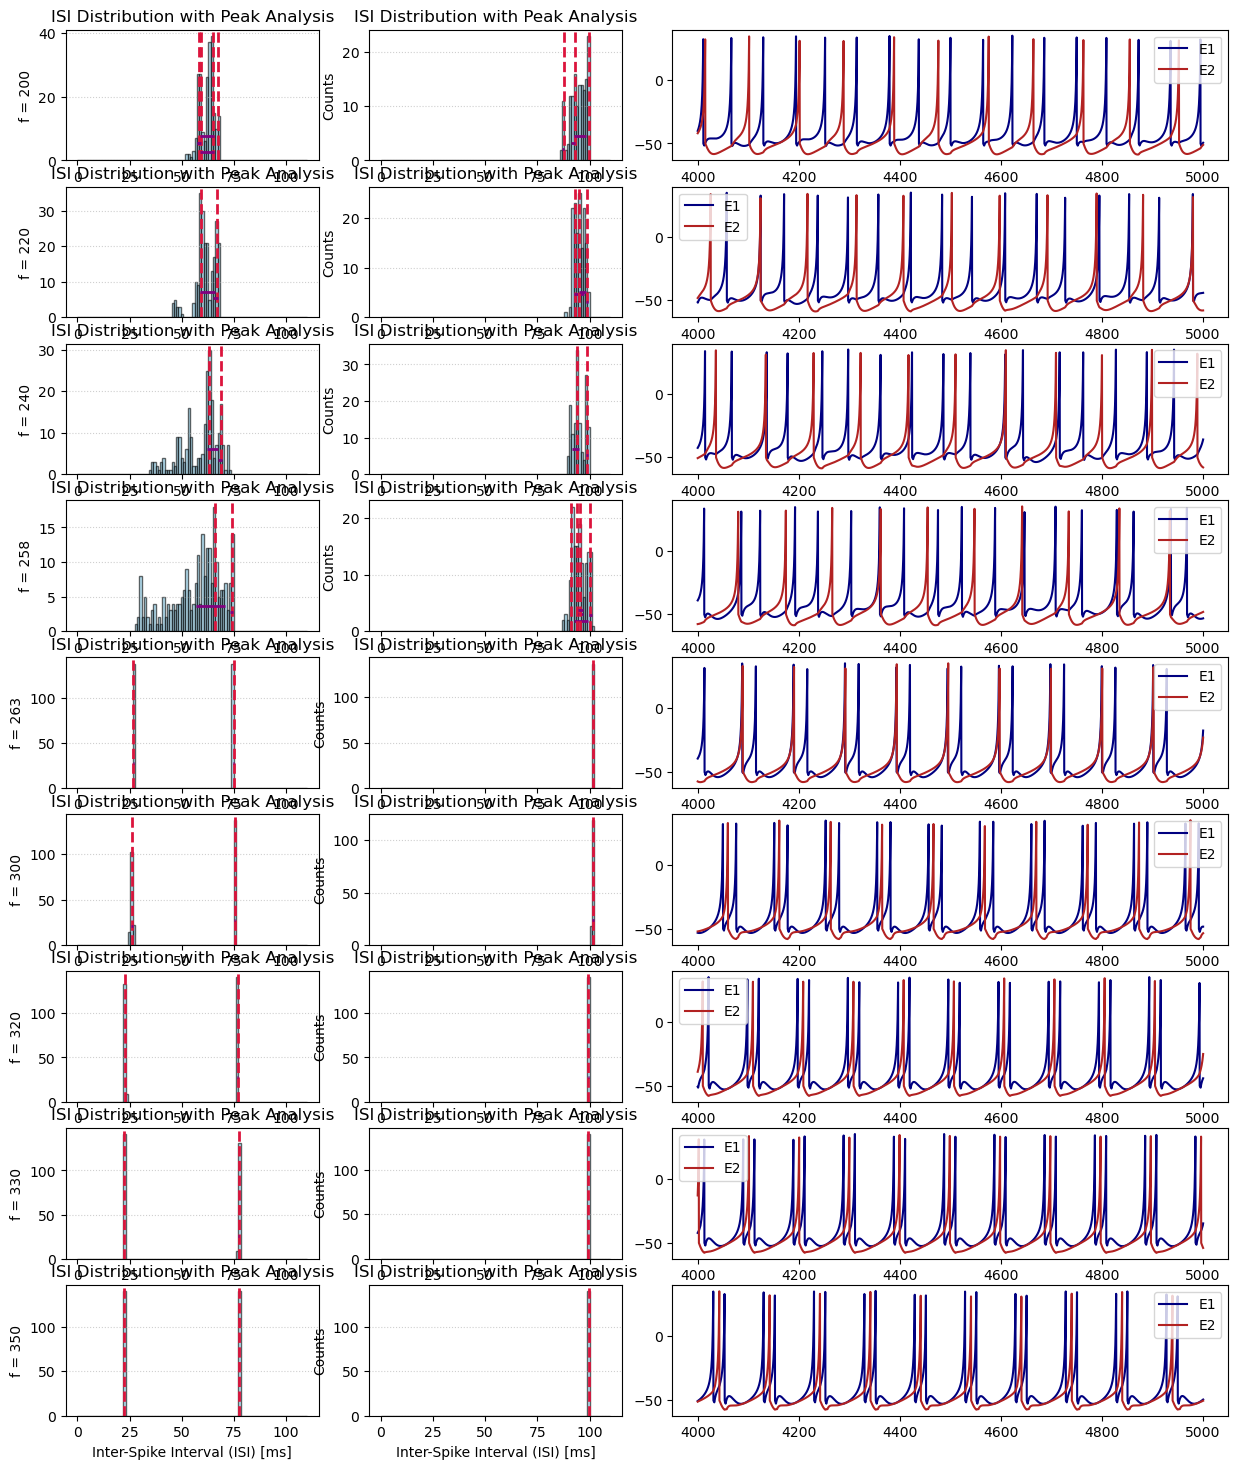

In [8]:
# plot ISI distributions for f1

fig3, ax3 = plot_peak_and_series(f3, idx3_arr, spikes_E1, spikes_E2, X_E1, X_E2, test200, f_vals, time)

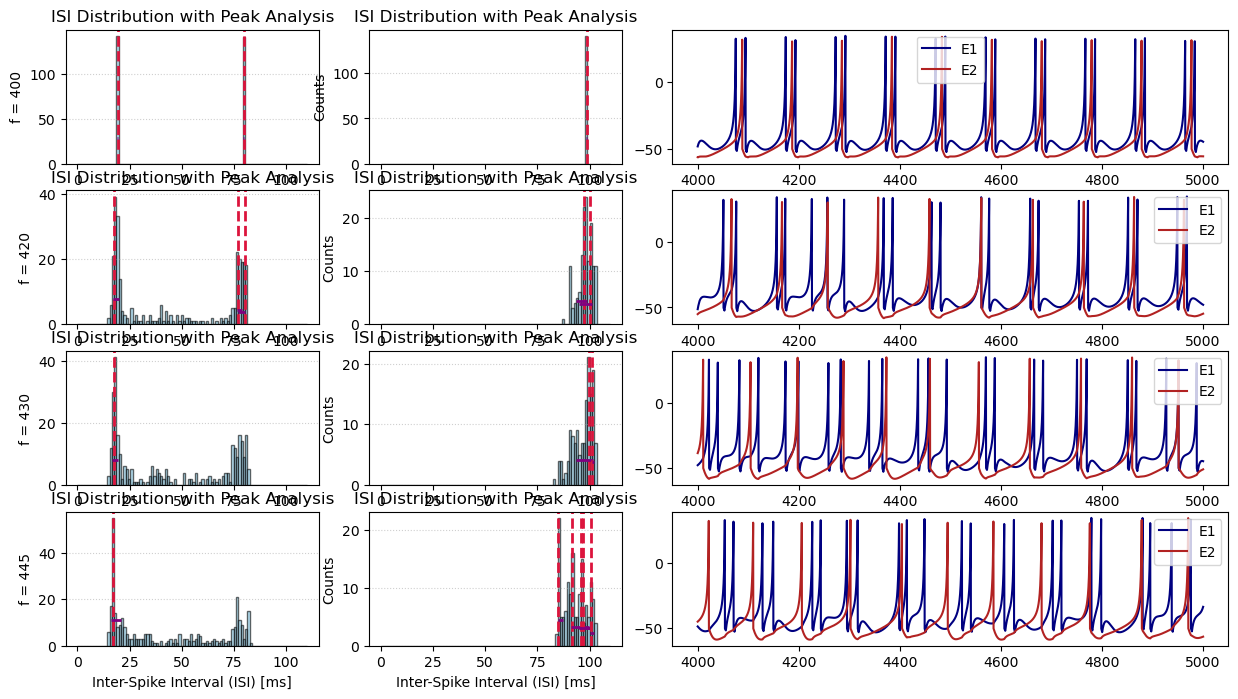

In [9]:
# plot ISI distributions for f4

fig4, ax4 = plot_peak_and_series(f4, idx4_arr, spikes_E1, spikes_E2, X_E1, X_E2, test200, f_vals, time)